In [3]:
import cv2

# Load the image in grayscale
img = cv2.imread('cameraman.png', cv2.IMREAD_GRAYSCALE)


In [4]:
# Set the threshold values
threshold_values = [0, 50, 100, 150, 200]

# Apply thresholding with different threshold values
for threshold_value in threshold_values:
    ret, thresh = cv2.threshold(img, threshold_value, 255, cv2.THRESH_BINARY)
    cv2.imshow(f'Thresholded Image ({threshold_value})', thresh)



QFontDatabase: Cannot find font directory /home/layanai/.local/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/layanai/.local/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/layanai/.local/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/layanai/.local/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/layanai/.local/lib/python3.12/si

In [5]:
# Display the original image
cv2.imshow('Original Image', img)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [6]:
# Task#2: Histogram Processing

# Step#1: Load necessary libraries
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

from skimage import data, img_as_float
from skimage import exposure

# Step#2: Load moon image
img = data.moon()


/home/layanai/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [7]:
# Step#3: Rescale intensity values to include all the intensities that fall within the 2nd and 98th percentiles
# Contrast stretching
p2, p98 = np.percentile(img, (2, 98))
img_rescale = exposure.rescale_intensity(img, in_range=(p2, p98))


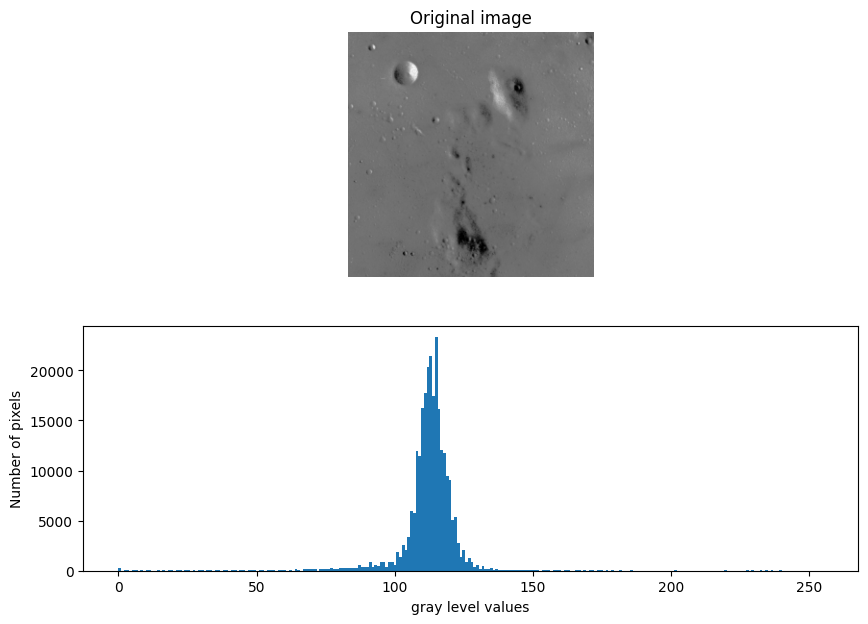

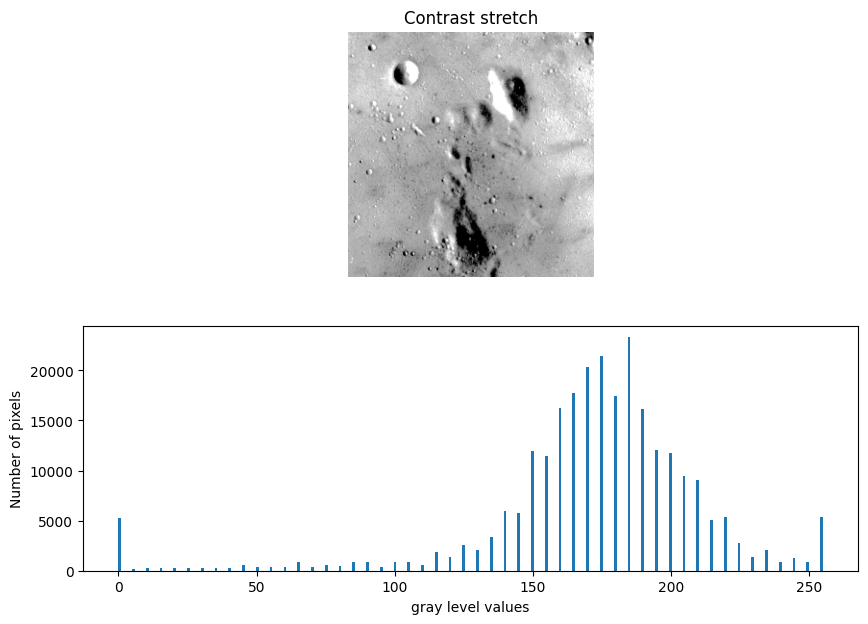

In [8]:
# Step#4: Display the image with its histogram of (step#2)  and (step#3)

fig = plt.figure(figsize=(10, 7)) 
fig.add_subplot(2, 1, 1) 
plt.imshow(img, cmap = 'gray') 
plt.axis('off') 
plt.title('Original image') 
fig.add_subplot(2, 1, 2) 
plt.hist(img.flat, bins = 256, range=(0, 255)) 
plt.xlabel('gray level values') 
plt.ylabel('Number of pixels') 
plt.show() 
fig = plt.figure(figsize=(10, 7)) 
fig.add_subplot(2, 1, 1) 
plt.imshow(img_rescale, cmap = 'gray') 
plt.axis('off') 
plt.title('Contrast stretch')
fig.add_subplot(2, 1, 2) 
plt.hist(img_rescale.flat, bins = 256, range=(0, 255)) 
plt.xlabel('gray level values') 
plt.ylabel('Number of pixels') 
plt.show() 

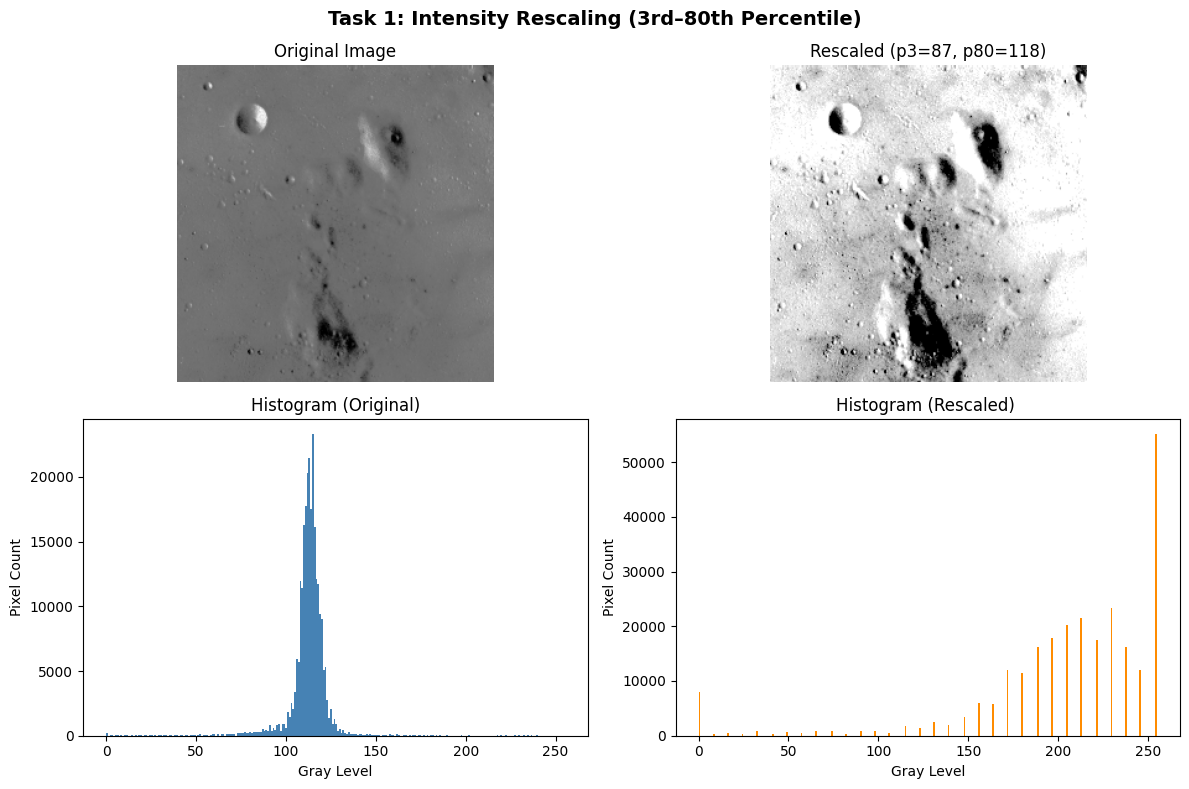

In [13]:
# Task#1: Using the same ‘moon image’ Rescale intensity values to include all the intensities that fall within the 3nd and 80th percentiles, and plot the histogram

moon = data.moon()
p3, p80 = np.percentile(moon, (3, 80))
moon_rescale = exposure.rescale_intensity(moon, in_range=(p3, p80))
 
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Task 1: Intensity Rescaling (3rd–80th Percentile)", fontsize=14, fontweight='bold')
 
axes[0, 0]. imshow (moon, cmap='gray')
axes[0, 0]. axis( 'off')
axes[0, 0]. set_title ('Original Image')
 
axes[0, 1]. imshow(moon_rescale, cmap='gray')
axes[0, 1]. axis('off')
axes[0, 1]. set_title (f'Rescaled (p3={p3:.0f}, p80={p80:.0f})')
 
axes[1, 0]. hist(moon.ravel(),  bins=256, range=(0, 255), color='steelblue')
axes[1, 0]. set_xlabel  ('Gray Level')
axes[1, 0] .set_ylabel ('Pixel Count')
axes[1, 0]. set_title ('Histogram (Original)')
 
axes[1, 1]. hist(moon_rescale.ravel(), bins=256, range=(0, 255), color='darkorange')
axes[1, 1]. set_xlabel ('Gray Level')
axes[1, 1]. set_ylabel ('Pixel Count')
axes[1, 1]. set_title('Histogram (Rescaled) ')
 
plt.tight_layout()
plt.show()


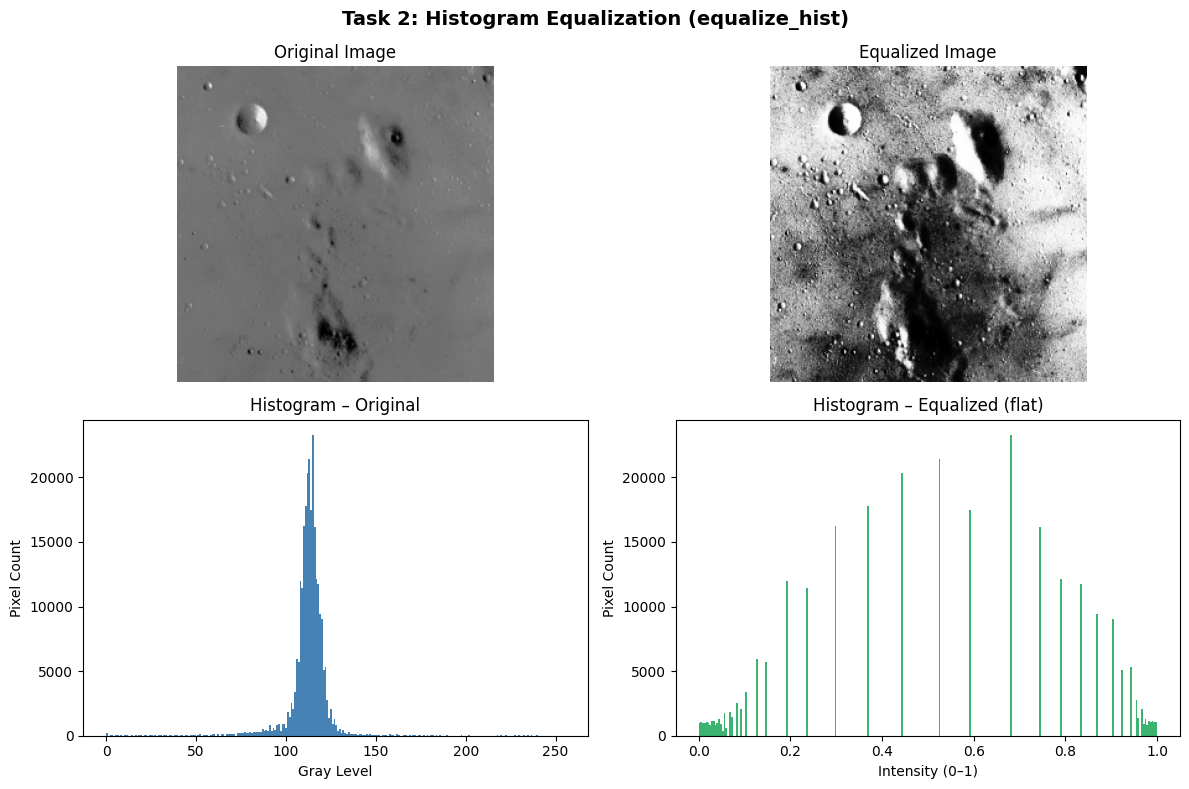

In [ ]:
# Task#2: Using the same ‘moon image’ and the exposure.equalize_hist function, display the image and the histogram of the image after flattening the histogram.

moon_eq = exposure.equalize_hist(moon)
 
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle ("Task 2: Histogram Equalization (equalize_hist)", fontsize=14, fontweight='bold')
 
axes[0, 0]. imshow(moon, cmap='gray')
axes[0, 0]. axis('off')
axes[0, 0]. set_title('Original Image')
 
axes[0, 1]. imshow(moon_eq, cmap='gray')
axes[0, 1]. axis('off')
axes[0, 1]. set_title('Equalized Image')
 
axes[1, 0]. hist(moon.ravel(), bins=256, range=(0, 255), color='steelblue')
axes[1, 0]. set_xlabel('Gray Level')
axes[1, 0]. set_ylabel('Pixel Count')
axes[1, 0]. set_title('Histogram – Original')

 
axes[1, 1]. hist(moon_eq.ravel(), bins=256, range=(0, 1), color='mediumseagreen')
axes[1, 1]. set_xlabel('Intensity (0–1)')
axes[1, 1]. set_ylabel('Pixel Count')
axes[1, 1]. set_title('Histogram – Equalized (flat)')
 
plt.tight_layout()
plt.show()

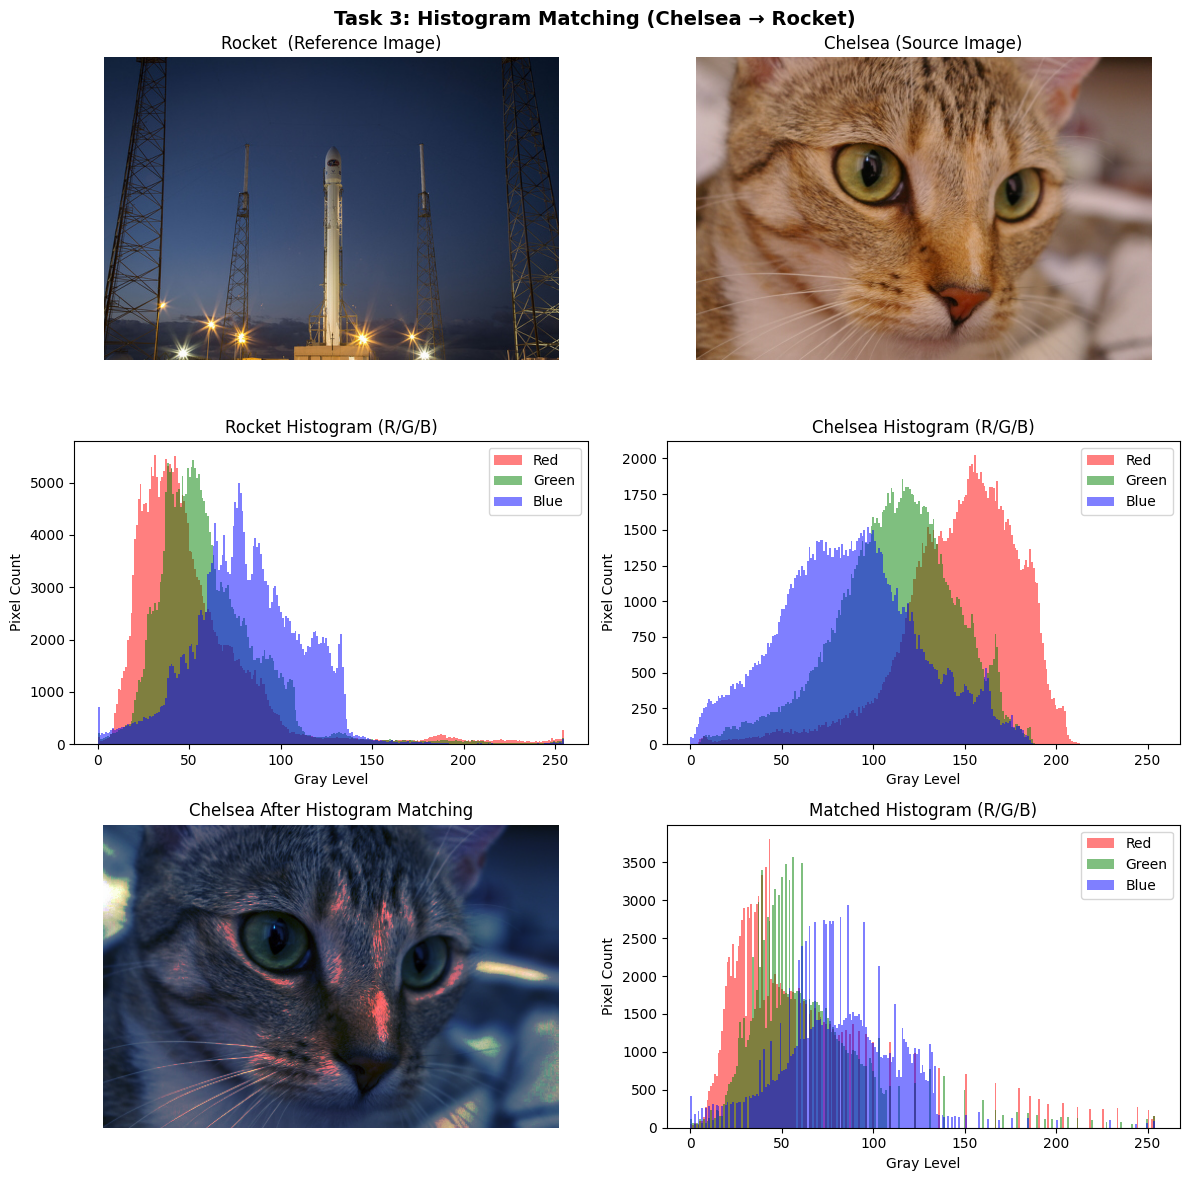

In [ ]:
# Task#3: Use the rocket (as reference) and chelsea images (from skimage.data) and implement histogram matching

chelsea = data.chelsea()
rocket  = data.rocket()    
matched = exposure.match_histograms(chelsea, rocket, channel_axis=-1)
 
fig, axes = plt.subplots(3, 2, figsize=(12, 12))
fig.suptitle("Task 3: Histogram Matching (Chelsea → Rocket)", fontsize=14, fontweight='bold')
 
axes[0, 0]. imshow(rocket)
axes[0, 0]. axis('off')
axes[0, 0]. set_title('Rocket  (Reference Image)')
  
  
axes[0, 1]. imshow(chelsea)
axes[0, 1]. axis('off')
axes[0, 1]. set_title('Chelsea (Source Image)')
 
for ch, col in zip(range(3), ['red', 'green', 'blue']):
    axes[1, 0].hist(rocket[:, :, ch].ravel(), bins=256, range=(0, 255), color=col, alpha=0.5, label=col.capitalize())
axes[1, 0].set_title('Rocket Histogram (R/G/B)')
axes[1, 0].set_xlabel('Gray Level')
axes[1, 0].set_ylabel('Pixel Count')
axes[1, 0].legend()
 
for ch, col in zip(range(3), ['red', 'green', 'blue']):
    axes[1, 1].hist(chelsea[:, :, ch].ravel(), bins=256, range=(0, 255), color=col, alpha=0.5, label=col.capitalize())
axes[1, 1].set_title('Chelsea Histogram (R/G/B)')
axes[1, 1].set_xlabel('Gray Level')
axes[1, 1].set_ylabel('Pixel Count')
axes[1, 1].legend()
 
 
axes[2, 0].imshow(matched.astype(np.uint8))
axes[2, 0].axis('off')
axes[2, 0].set_title('Chelsea After Histogram Matching')
 
 
 
for ch, col in zip(range(3), ['red', 'green', 'blue']):
    axes[2, 1].hist(matched[:, :, ch].ravel(), bins=256, range=(0, 255), color=col, alpha=0.5, label=col.capitalize())
axes[2, 1].set_title('Matched Histogram (R/G/B)')
axes[2, 1].set_xlabel('Gray Level')
axes[2, 1].set_ylabel('Pixel Count')
axes[2, 1].legend()

 
plt.tight_layout()
plt.show()